In [1]:
# notebooks/04_explainability.ipynb

import pandas as pd
import numpy as np
import shap
import pickle
import os
import matplotlib.pyplot as plt

In [2]:
# Load best model
with open("../models/best_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load test data
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# Create plots folder
os.makedirs("plots", exist_ok=True)

print("Model and data loaded successfully")

Model and data loaded successfully


In [3]:
# For tree-based models (LightGBM, XGBoost, Random Forest)
explainer = shap.Explainer(model, X_test)

# Generate SHAP values
shap_values = explainer(X_test)

print("SHAP values generated")

 96%|=================== | 1349/1409 [00:16<00:00]       

SHAP values generated


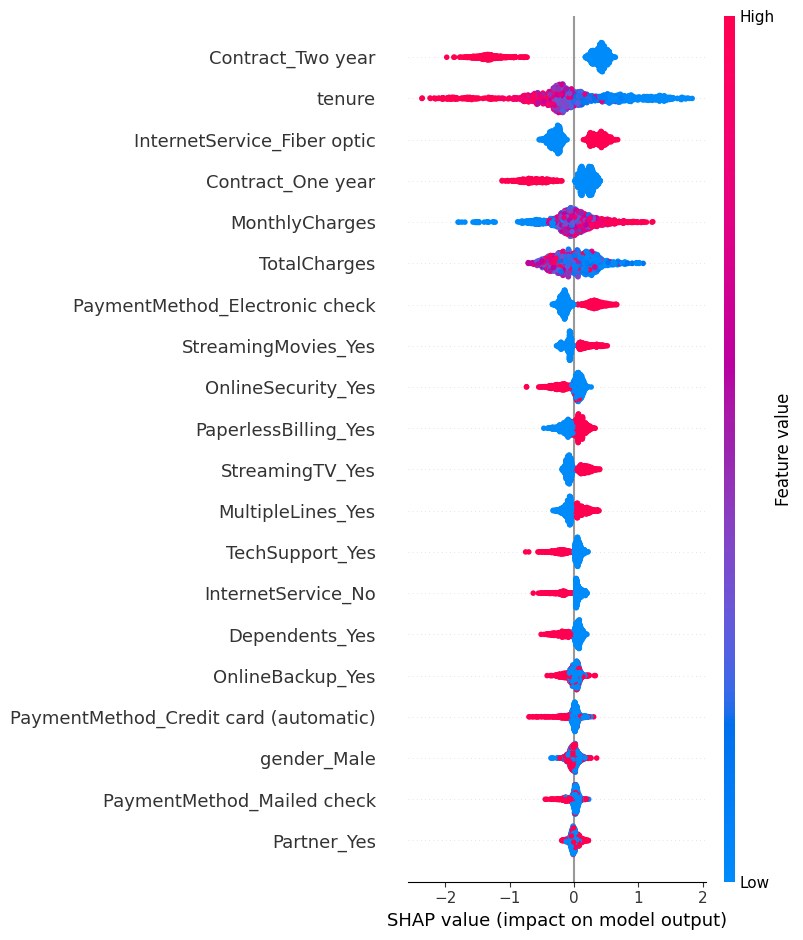

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("plots/shap_summary.png", bbox_inches='tight')
plt.show()

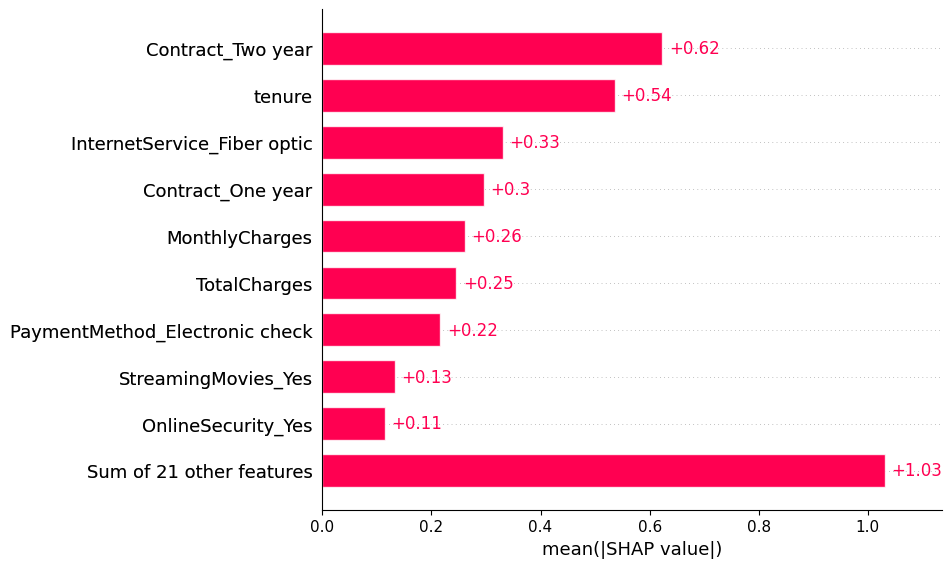

In [5]:
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.savefig("plots/shap_bar.png", bbox_inches='tight')
plt.show()

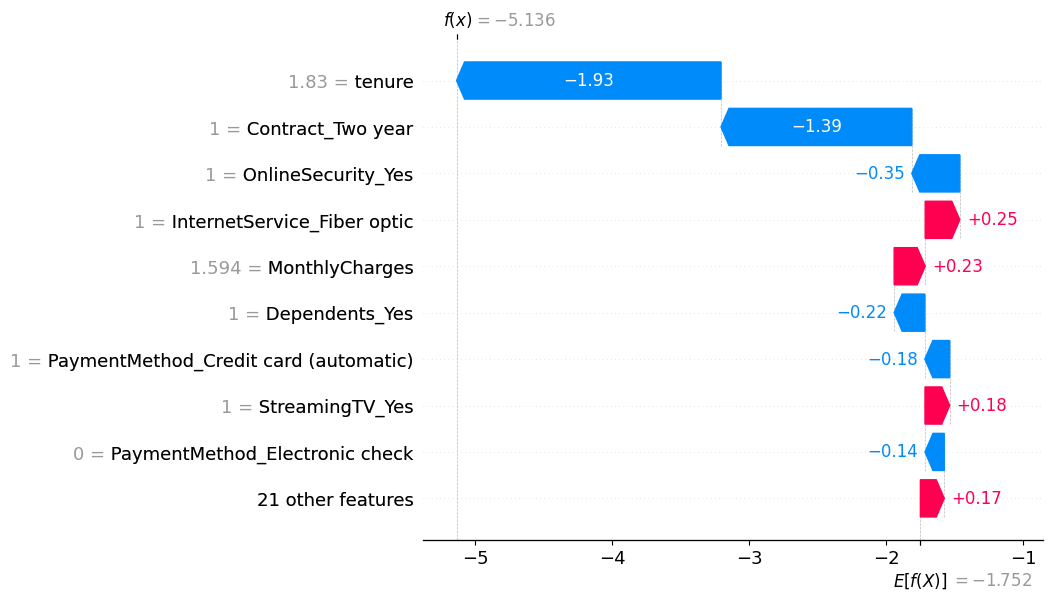

In [6]:
# Pick one customer
index = 0

plt.figure()
shap.plots.waterfall(shap_values[index], show=False)
plt.savefig("plots/shap_waterfall.png", bbox_inches='tight')
plt.show()

In [7]:
# Get feature impact for one customer
shap_vals = shap_values[index].values
feature_names = X_test.columns

impact_df = pd.DataFrame({
    "Feature": feature_names,
    "Impact": shap_vals
})

impact_df["AbsImpact"] = np.abs(impact_df["Impact"])
top_features = impact_df.sort_values(by="AbsImpact", ascending=False).head(3)

top_features

,Feature,Impact,AbsImpact
1,tenure,-1.929506,1.929506
25,Contract_Two year,-1.392155,1.392155
13,OnlineSecurity_Yes,-0.350272,0.350272


In [8]:
print("Base value (average prediction):", explainer.expected_value)

Base value (average prediction): -1.7518516890701747
